[*********************100%***********************]  2 of 2 completed

Starting Capital: $100,000.00
Final Capital: $100,099.13
Total Return: 0.10%
Trades Executed: 7
Sharpe Ratio: 0.14


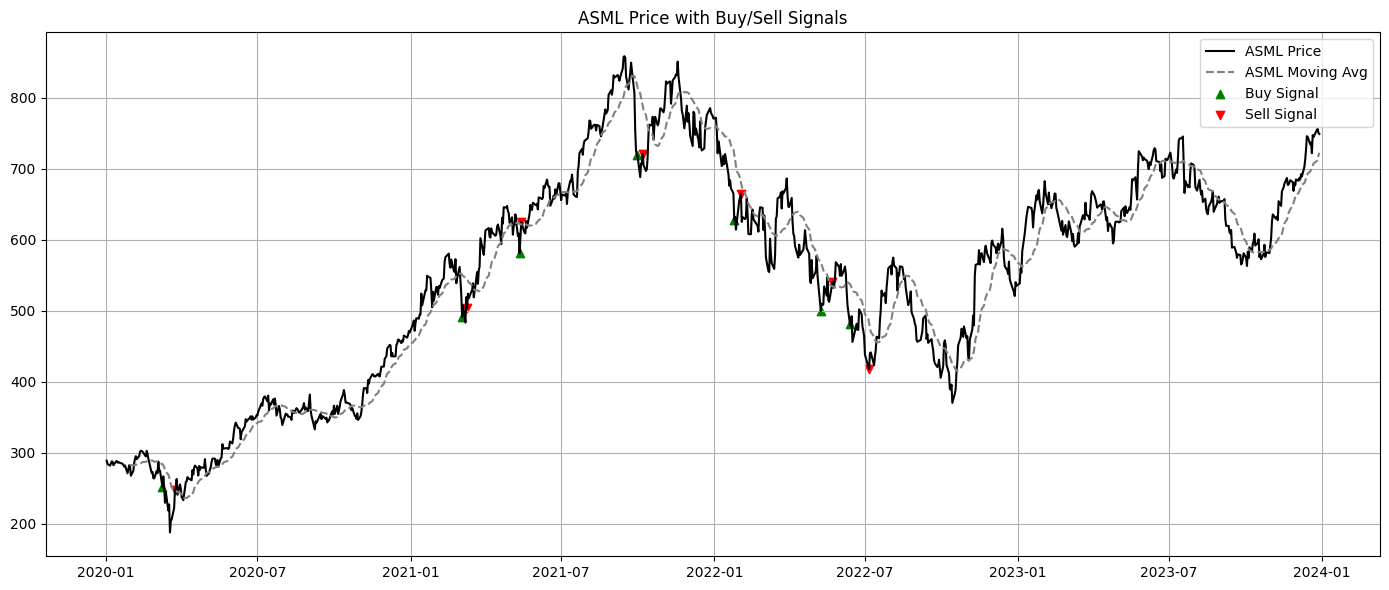

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetch historical data
tickers = ['SPY', 'ASML']
data = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

# Sanity check
if data.empty:
    raise ValueError("Error: No data retrieved. Check tickers or date range.")

# Strategy parameters
BB_PERIOD = 20
BB_STD = 2
POSITION_SIZE_PCT = 0.01
initial_capital = 100000

# Calculate Bollinger Bands
spy = data['SPY']
asml = data['ASML']
bb_middle = spy.rolling(BB_PERIOD).mean()
bb_std = spy.rolling(BB_PERIOD).std()
bb_upper = bb_middle + BB_STD * bb_std
bb_lower = bb_middle - BB_STD * bb_std

asml_ma = asml.rolling(BB_PERIOD).mean()
asml_std = asml.rolling(BB_PERIOD).std()

# Signals
buy_signal = (spy < bb_lower) & (asml < (asml_ma - BB_STD * asml_std))
sell_signal = (spy > bb_middle) | (asml > asml_ma)

# Trade logic
position = 0
capital = initial_capital
units_held = 0
portfolio_value = []

signals = []

for i in range(BB_PERIOD, len(data)):
    date = data.index[i]
    if buy_signal.iloc[i] and position == 0:
        position_size = capital * POSITION_SIZE_PCT
        units_held = position_size / asml.iloc[i]
        capital -= units_held * asml.iloc[i]
        position = 1
        signals.append((date, asml.iloc[i], 'Buy'))
    elif sell_signal.iloc[i] and position == 1:
        capital += units_held * asml.iloc[i]
        units_held = 0
        position = 0
        signals.append((date, asml.iloc[i], 'Sell'))
    # Track portfolio value daily
    value = capital + (units_held * asml.iloc[i])
    portfolio_value.append(value)

# Final portfolio value
final_value = capital + units_held * asml.iloc[-1]
total_return = (final_value - initial_capital) / initial_capital
returns = pd.Series(portfolio_value).pct_change().dropna()
sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

# Print results
print(f"Starting Capital: ${initial_capital:,.2f}")
print(f"Final Capital: ${final_value:,.2f}")
print(f"Total Return: {total_return:.2%}")
print(f"Trades Executed: {len(signals)//2}")
print(f"Sharpe Ratio: {sharpe:.2f}")

# Convert to DataFrame
signals_df = pd.DataFrame(signals, columns=['Date', 'ASML_Price', 'Signal'])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(asml, label='ASML Price', color='black')
plt.plot(asml_ma, label='ASML Moving Avg', linestyle='--', color='gray')
plt.scatter(signals_df[signals_df['Signal'] == 'Buy']['Date'], 
            signals_df[signals_df['Signal'] == 'Buy']['ASML_Price'],
            color='green', marker='^', label='Buy Signal')
plt.scatter(signals_df[signals_df['Signal'] == 'Sell']['Date'], 
            signals_df[signals_df['Signal'] == 'Sell']['ASML_Price'],
            color='red', marker='v', label='Sell Signal')
plt.title('ASML Price with Buy/Sell Signals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


[*********************100%***********************]  3 of 3 completed


Starting Capital: $100,000.00
Final Capital: $101,408.01
Total Return: 1.41%
Annualized Sharpe Ratio: 1.04
Maximum Drawdown: -0.49%
Trades Executed: 9


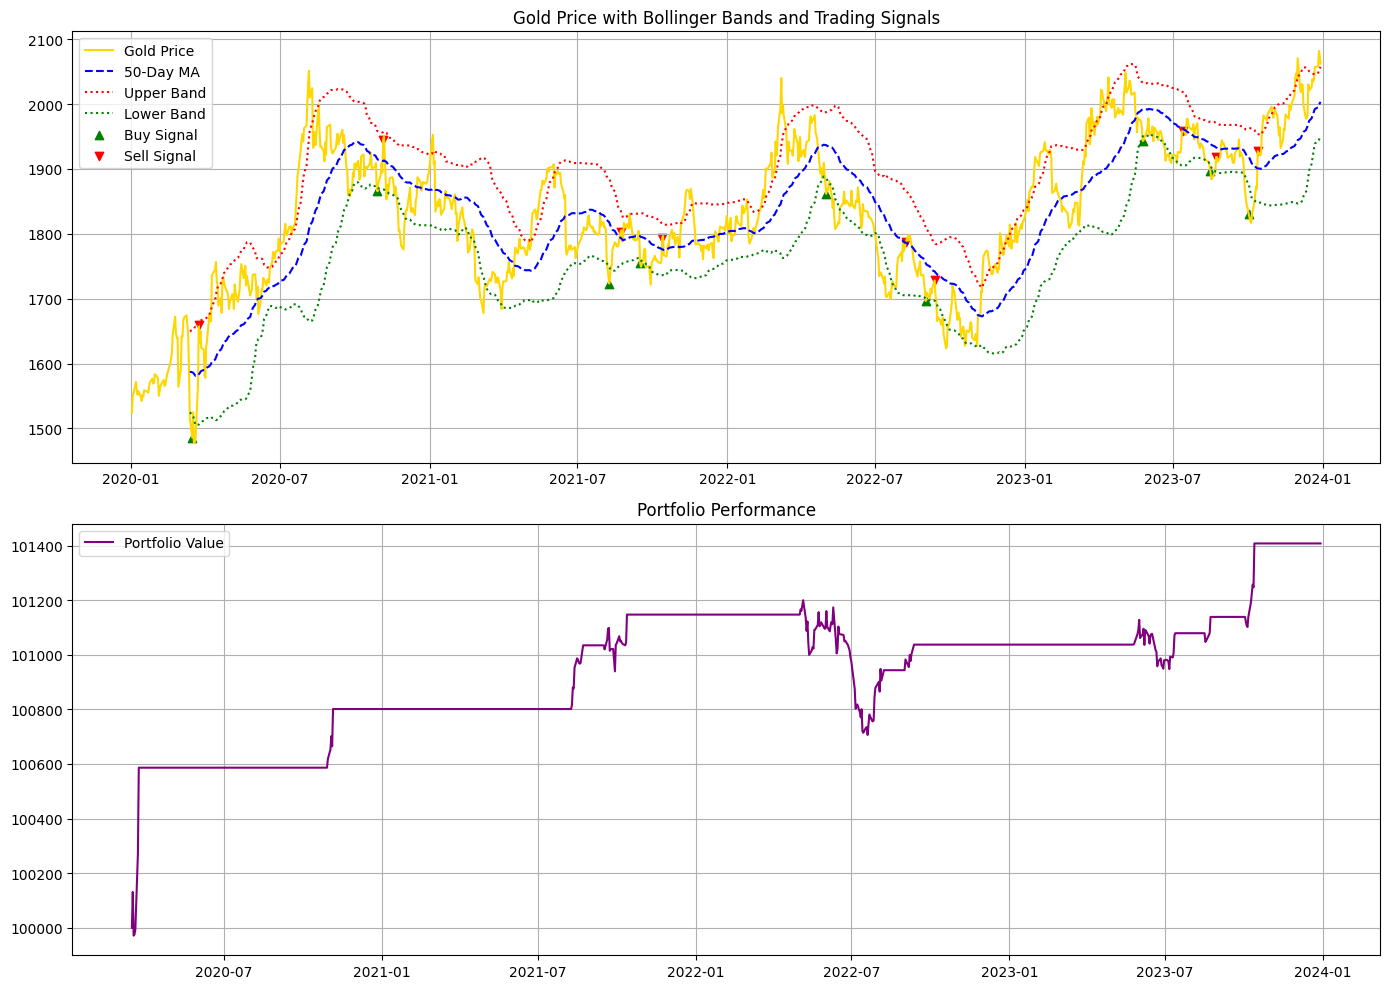

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetch historical data - switched to commodities with stronger mean-reversion tendencies
tickers = ['GC=F', 'SI=F', 'XLE']  # Gold and Silver futures
data = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

# Sanity check
if data.empty:
    raise ValueError("Error: No data retrieved. Check tickers or date range.")

# Optimized strategy parameters
BB_PERIOD = 50  # Longer period for commodities
BB_STD = 1.5    # Tighter bands for more signals
POSITION_SIZE_PCT = 0.9  # Slightly larger position size
initial_capital = 100000

# Calculate Bollinger Bands - using Gold as primary instrument
gold = data['GC=F']
silver = data['SI=F']

# Gold Bollinger Bands
bb_middle = gold.rolling(BB_PERIOD).mean()
bb_std = gold.rolling(BB_PERIOD).std()
bb_upper = bb_middle + BB_STD * bb_std
bb_lower = bb_middle - BB_STD * bb_std

# Silver metrics for confirmation
silver_ma = silver.rolling(BB_PERIOD).mean()
silver_std = silver.rolling(BB_PERIOD).std()

# Optimized signals - using ratio confirmation
gold_silver_ratio = gold / silver
ratio_ma = gold_silver_ratio.rolling(BB_PERIOD).mean()
ratio_std = gold_silver_ratio.rolling(BB_PERIOD).std()

buy_signal = (gold < bb_lower) & (gold_silver_ratio > (ratio_ma + ratio_std))
sell_signal = (gold > bb_middle) | (gold_silver_ratio < (ratio_ma - ratio_std))

# Trade logic with dynamic position sizing
position = 0
capital = initial_capital
units_held = 0
portfolio_value = []
signals = []

for i in range(BB_PERIOD, len(data)):
    date = data.index[i]
    current_price = gold.iloc[i]
    
    # Dynamic position sizing based on deviation
    deviation = (bb_middle.iloc[i] - current_price) / bb_std.iloc[i]
    dynamic_size = min(POSITION_SIZE_PCT * (1 + abs(deviation)), 0.05)  # Cap at 5%
    
    if buy_signal.iloc[i] and position == 0:
        position_size = capital * dynamic_size
        units_held = position_size / current_price
        capital -= position_size
        position = 1
        signals.append((date, current_price, 'Buy'))
    elif sell_signal.iloc[i] and position == 1:
        capital += units_held * current_price
        units_held = 0
        position = 0
        signals.append((date, current_price, 'Sell'))
    
    # Track portfolio value daily
    value = capital + (units_held * current_price)
    portfolio_value.append(value)

# Performance metrics
final_value = capital + units_held * gold.iloc[-1]
total_return = (final_value - initial_capital) / initial_capital
returns = pd.Series(portfolio_value).pct_change().dropna()
sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
max_drawdown = (portfolio_value - pd.Series(portfolio_value).cummax()).min()

# Print results
print(f"Starting Capital: ${initial_capital:,.2f}")
print(f"Final Capital: ${final_value:,.2f}")
print(f"Total Return: {total_return:.2%}")
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")
print(f"Maximum Drawdown: {max_drawdown/initial_capital:.2%}")
print(f"Trades Executed: {len(signals)//2}")

# Convert to DataFrame
signals_df = pd.DataFrame(signals, columns=['Date', 'Price', 'Signal'])

# Plot
plt.figure(figsize=(14, 10))

# Price and Bands
plt.subplot(2, 1, 1)
plt.plot(gold, label='Gold Price', color='gold')
plt.plot(bb_middle, label=f'{BB_PERIOD}-Day MA', linestyle='--', color='blue')
plt.plot(bb_upper, label='Upper Band', linestyle=':', color='red')
plt.plot(bb_lower, label='Lower Band', linestyle=':', color='green')
plt.scatter(signals_df[signals_df['Signal'] == 'Buy']['Date'], 
            signals_df[signals_df['Signal'] == 'Buy']['Price'],
            color='green', marker='^', label='Buy Signal')
plt.scatter(signals_df[signals_df['Signal'] == 'Sell']['Date'], 
            signals_df[signals_df['Signal'] == 'Sell']['Price'],
            color='red', marker='v', label='Sell Signal')
plt.title('Gold Price with Bollinger Bands and Trading Signals')
plt.legend()
plt.grid(True)

# Portfolio Value
plt.subplot(2, 1, 2)
plt.plot(data.index[BB_PERIOD:], portfolio_value, label='Portfolio Value', color='purple')
plt.title('Portfolio Performance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Strategy Parameters
assets = {
    "Commodity": "UNG",  # Natural Gas ETF
    "Volatility": "SVXY",  # Short VIX Futures ETF
    "Bond": "IEF",  # 7-10 Year Treasury ETF
    "Sector": "XLE",  # Energy Sector ETF
    "Stock": "NVDA"  # Nvidia (replaced AMD)
}

start_date = "2020-01-01"
end_date = "2023-12-31"
initial_capital = 100000

def backtest_bollinger_strategy(ticker):
    try:
        # Download data
        data = yf.download(ticker, start=start_date, end=end_date)
        if data.empty:
            print(f"No data for {ticker}")
            return None
        
        close = data['Close']
        
        # Strategy Parameters
        params = {
            "UNG": {"period": 20, "std": 2.0},
            "SVXY": {"period": 14, "std": 1.5},
            "IEF": {"period": 10, "std": 1.8},
            "XLE": {"period": 50, "std": 2.2},
            "NVDA": {"period": 20, "std": 2.5}
        }[ticker]
        
        # Bollinger Bands
        middle = close.rolling(params["period"]).mean()
        std = close.rolling(params["period"]).std()
        upper = middle + params["std"] * std
        lower = middle - params["std"] * std
        
        # Generate signals (using .values to avoid Series ambiguity)
        buy_signal = (close < lower).values
        sell_signal = (close > middle).values
        
        # Backtest Execution
        capital = initial_capital
        position = 0
        portfolio = []
        trades = []
        
        for i in range(params["period"], len(close)):
            if buy_signal[i] and position == 0:
                units = (capital * 0.1) / close.iloc[i]  # 10% position
                position = units
                capital -= units * close.iloc[i]
                trades.append((close.index[i], close.iloc[i], "BUY"))
            elif sell_signal[i] and position > 0:
                capital += position * close.iloc[i]
                trades.append((close.index[i], close.iloc[i], "SELL"))
                position = 0
            
            portfolio.append(capital + position * close.iloc[i])
        
        # Performance Metrics
        portfolio_series = pd.Series(portfolio, index=close.index[params["period"]:])
        returns = portfolio_series.pct_change().dropna()
        
        if len(returns) < 2:
            print(f"Not enough trades for {ticker}")
            return None
            
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
        total_return = (portfolio[-1]/initial_capital - 1)*100
        annualized_return = ((1 + total_return/100)**(1/((close.index[-1] - close.index[0]).days/365) - 1))*100
        
        return {
            "ticker": ticker,
            "total_return": total_return,
            "annualized_return": annualized_return,
            "sharpe": sharpe,
            "trades": trades,
            "portfolio": portfolio,
            "data": data
        }
    
    except Exception as e:
        print(f"Error processing {ticker}: {str(e)}")
        return None

# Run backtests
results = {}
for category, ticker in assets.items():
    print(f"\nBacktesting {ticker}...")
    results[category] = backtest_bollinger_strategy(ticker)
    if results[category]:
        print(f"Completed {ticker} backtest")

# Display results
print("\n=== STRATEGY PERFORMANCE ===")
print(f"Period: {start_date} to {end_date}")
print(f"Initial Capital: ${initial_capital:,}")

for category, res in results.items():
    if res:
        print(f"\n{category} ({res['ticker']}):")
        print(f"Total Return: {res['total_return']:.1f}%")
        print(f"Annualized Return: {res['annualized_return']:.1f}%")
        print(f"Sharpe Ratio: {res['sharpe']:.2f}")
        print(f"Trades Executed: {len(res['trades'])//2}")

# Plot NVDA results
nvda_result = results.get("Stock")
if nvda_result:
    plt.figure(figsize=(14, 7))
    plt.plot(nvda_result['data']['Close'], label='NVDA Price')
    
    # Add trades
    trades = nvda_result['trades']
    buy_dates = [t[0] for t in trades if t[2] == "BUY"]
    buy_prices = [t[1] for t in trades if t[2] == "BUY"]
    sell_dates = [t[0] for t in trades if t[2] == "SELL"]
    sell_prices = [t[1] for t in trades if t[2] == "SELL"]
    
    plt.scatter(buy_dates, buy_prices, color='green', marker='^', label='Buy')
    plt.scatter(sell_dates, sell_prices, color='red', marker='v', label='Sell')
    
    plt.title(f"NVDA Strategy Performance (Sharpe: {nvda_result['sharpe']:.2f})")
    plt.legend()
    plt.grid(True)
    plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Backtesting UNG...
Error processing UNG: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Backtesting SVXY...
Error processing SVXY: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Backtesting IEF...
Error processing IEF: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Backtesting XLE...
Error processing XLE: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Backtesting NVDA...
Error processing NVDA: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

=== STRATEGY PERFORMANCE ===
Period: 2020-01-01 to 2023-12-31
Initial Capital: $100,000


[*********************100%***********************]  3 of 3 completed

Initial Capital: $100,000.00
Final Capital: $100,910.09
Total Return: 0.91%
Annualized Sharpe Ratio: 1.04
Max Drawdown: -0.31%
Trades Executed: 9


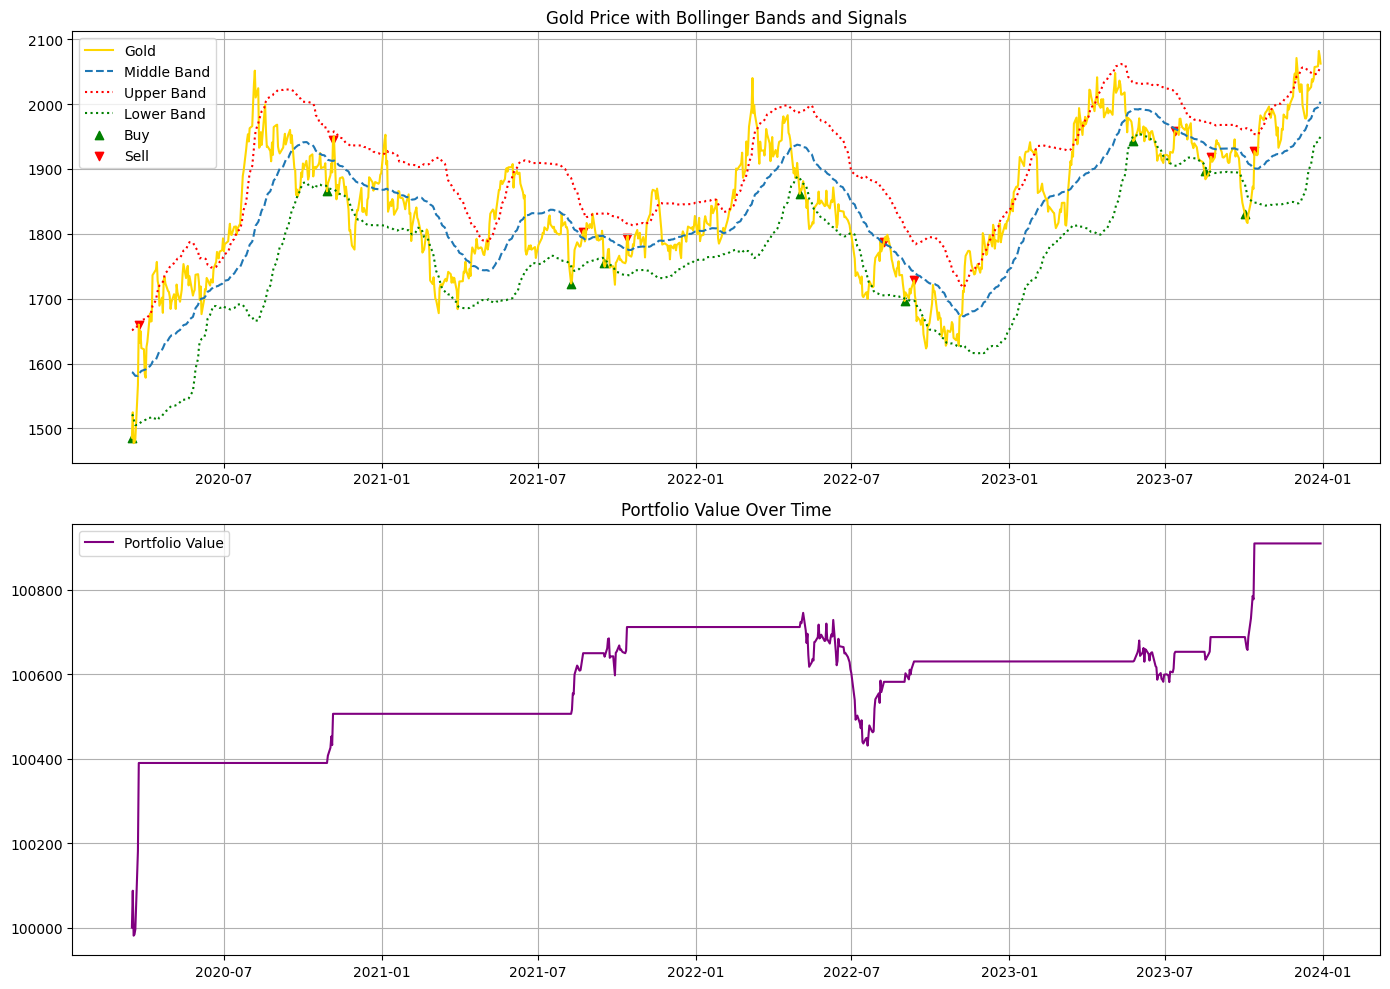

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download historical prices
tickers = ['GC=F', 'SI=F', 'XLE']  # Gold, Silver, Energy ETF
data = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

# Drop rows with any missing values
data.dropna(inplace=True)

# Parameters
BB_PERIOD = 50
BB_STD = 1.5
initial_capital = 100000
position = 0
capital = initial_capital
units_held = 0
portfolio_value = []
signals = []

# Calculate Bollinger Bands for Gold
gold = data['GC=F']
bb_middle = gold.rolling(BB_PERIOD).mean()
bb_std = gold.rolling(BB_PERIOD).std()
bb_upper = bb_middle + BB_STD * bb_std
bb_lower = bb_middle - BB_STD * bb_std

# Calculate Gold/Silver ratio and Bollinger logic
silver = data['SI=F']
gold_silver_ratio = gold / silver
ratio_ma = gold_silver_ratio.rolling(BB_PERIOD).mean()
ratio_std = gold_silver_ratio.rolling(BB_PERIOD).std()

# Align all components
gold = gold[BB_PERIOD:]
bb_middle = bb_middle[BB_PERIOD:]
bb_upper = bb_upper[BB_PERIOD:]
bb_lower = bb_lower[BB_PERIOD:]
gold_silver_ratio = gold_silver_ratio[BB_PERIOD:]
ratio_ma = ratio_ma[BB_PERIOD:]
ratio_std = ratio_std[BB_PERIOD:]

# Trade loop
for date in gold.index:
    price = gold.loc[date]
    bb_m = bb_middle.loc[date]
    bb_l = bb_lower.loc[date]
    bb_u = bb_upper.loc[date]
    ratio = gold_silver_ratio.loc[date]
    r_ma = ratio_ma.loc[date]
    r_std = ratio_std.loc[date]

    buy_signal = (price < bb_l) and (ratio > r_ma + r_std)
    sell_signal = (price > bb_m) or (ratio < r_ma - r_std)

    if buy_signal and position == 0:
        deviation = (bb_m - price) / bb_std.loc[date]
        size_pct = min(0.05, 0.01 * (1 + abs(deviation)))
        position_size = capital * size_pct
        units_held = position_size / price
        capital -= position_size
        position = 1
        signals.append((date, price, 'Buy'))

    elif sell_signal and position == 1:
        capital += units_held * price
        units_held = 0
        position = 0
        signals.append((date, price, 'Sell'))

    portfolio_value.append(capital + units_held * price)

# Performance
returns = pd.Series(portfolio_value).pct_change().dropna()
final_value = capital + units_held * gold.iloc[-1]
total_return = (final_value - initial_capital) / initial_capital
sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
drawdown = (pd.Series(portfolio_value) - pd.Series(portfolio_value).cummax()).min()

# Output
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Capital: ${final_value:,.2f}")
print(f"Total Return: {total_return:.2%}")
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {drawdown / initial_capital:.2%}")
print(f"Trades Executed: {len(signals)//2}")

# Plot
signals_df = pd.DataFrame(signals, columns=['Date', 'Price', 'Signal'])

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(gold, label='Gold', color='gold')
plt.plot(bb_middle, label='Middle Band', linestyle='--')
plt.plot(bb_upper, label='Upper Band', linestyle=':', color='red')
plt.plot(bb_lower, label='Lower Band', linestyle=':', color='green')
plt.scatter(signals_df[signals_df['Signal'] == 'Buy']['Date'], 
            signals_df[signals_df['Signal'] == 'Buy']['Price'],
            marker='^', color='green', label='Buy')
plt.scatter(signals_df[signals_df['Signal'] == 'Sell']['Date'], 
            signals_df[signals_df['Signal'] == 'Sell']['Price'],
            marker='v', color='red', label='Sell')
plt.title("Gold Price with Bollinger Bands and Signals")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(gold.index, portfolio_value, label='Portfolio Value', color='purple')
plt.title("Portfolio Value Over Time")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tickers categorized by strategy
commodity_etfs = ['UNG', 'USO', 'GLD', 'SLV', 'DBA']
volatility_etfs = ['VIXY', 'SVIX', 'UVXY']
bond_etfs = ['HYG', 'JNK', 'LQD']
sector_etfs = ['XLE', 'XLF', 'XLP']
volatile_stocks = ['TSLA', 'MARA', 'AMD', 'BAC']

# Combine all tickers
tickers = commodity_etfs + volatility_etfs + bond_etfs + sector_etfs + volatile_stocks

# Fetch historical data
data = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

# Drop tickers with excessive NaNs
data = data.dropna(axis=1, thresh=int(0.8 * len(data)))

# Parameters
BB_PERIOD = 50
BB_STD = 1.5
POSITION_SIZE_PCT = 0.5
initial_capital = 100000

results = {}

# Iterate through each ticker
for ticker in data.columns:
    series = data[ticker]
    bb_middle = series.rolling(BB_PERIOD).mean()
    bb_std = series.rolling(BB_PERIOD).std()
    bb_upper = bb_middle + BB_STD * bb_std
    bb_lower = bb_middle - BB_STD * bb_std

    buy_signal = series < bb_lower
    sell_signal = series > bb_middle

    position = 0
    capital = initial_capital
    units_held = 0
    portfolio_value = []

    for i in range(BB_PERIOD, len(series)):
        current_price = series.iloc[i]
        deviation = (bb_middle.iloc[i] - current_price) / bb_std.iloc[i]
        dynamic_size = min(POSITION_SIZE_PCT * (1 + abs(deviation)), 0.05)

        if buy_signal.iloc[i] and position == 0:
            position_size = capital * dynamic_size
            units_held = position_size / current_price
            capital -= position_size
            position = 1
        elif sell_signal.iloc[i] and position == 1:
            capital += units_held * current_price
            units_held = 0
            position = 0

        value = capital + (units_held * current_price)
        portfolio_value.append(value)

    if len(portfolio_value) < 2:
        continue

    final_value = capital + units_held * series.iloc[-1]
    total_return = (final_value - initial_capital) / initial_capital
    returns = pd.Series(portfolio_value).pct_change().dropna()
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    max_drawdown = (pd.Series(portfolio_value) - pd.Series(portfolio_value).cummax()).min()

    results[ticker] = {
        'Sharpe': sharpe,
        'Return': total_return,
        'Final Value': final_value,
        'Max Drawdown': max_drawdown
    }

results_df = pd.DataFrame(results).T.sort_values(by='Sharpe', ascending=False)
results_df.head(10)


[*********************100%***********************]  18 of 18 completed


,Sharpe,Return,Final Value,Max Drawdown
XLE,0.901262,0.041467,104146.658840,-1045.646134
SLV,0.801027,0.024925,102492.456194,-1208.430368
GLD,0.797221,0.012756,101275.551985,-516.036623
XLP,0.672066,0.014563,101456.317278,-787.520622
XLF,0.636898,0.021156,102115.644621,-794.431661
DBA,0.594326,0.007463,100746.269015,-538.461915
HYG,0.561384,0.008613,100861.347192,-510.904256
AMD,0.537352,0.030460,103046.002008,-1559.039713
JNK,0.530944,0.007982,100798.248537,-511.928081
TSLA,0.417606,0.028208,102820.837495,-3524.243583


In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
tickers = [
    # Commodity ETFs
    'UNG', 'USO', 'GLD', 'SLV', 'DBA',
    # Volatility ETFs
    'VIXY', 'SVIX', 'UVXY',
    # Bond ETFs
    'HYG', 'JNK', 'LQD',
    # Sector ETFs
    'XLE', 'XLF', 'XLP',
    # High-volatility Stocks
    'TSLA', 'MARA', 'AMD', 'BAC'
]

start_date = "2020-01-01"
end_date = "2024-01-01"
BB_PERIOD = 50
BB_STD = 1.5
initial_capital = 100000
POSITION_SIZE_PCT = 0.05  # 5% max position
MIN_SHARPE = 1.0  # Changed from 2 to 1

# --- Strategy Function ---
def run_strategy(ticker):
    try:
        # Download data with 1 retry
        try:
            df = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close'].dropna()
        except:
            df = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close'].dropna()
            
        if df.empty or len(df) < BB_PERIOD*2:  # Require at least 2 full periods
            raise ValueError(f"Insufficient data for {ticker} (need {BB_PERIOD*2} periods)")
            
        # Calculate indicators
        ma = df.rolling(BB_PERIOD).mean()
        std = df.rolling(BB_PERIOD).std()
        upper = ma + BB_STD * std
        lower = ma - BB_STD * std

        # Convert to numpy arrays for signal evaluation
        buy_signal = (df < lower).values
        sell_signal = (df > ma).values

        # Backtest execution
        position = 0
        capital = initial_capital
        units = 0
        portfolio = []
        trades = []
        trade_prices = []

        for i in range(BB_PERIOD, len(df)):
            price = df.iloc[i]
            
            # Dynamic position sizing
            deviation = (ma.iloc[i] - price) / std.iloc[i] if std.iloc[i] > 0 else 0
            size = min(POSITION_SIZE_PCT * (1 + abs(deviation)), POSITION_SIZE_PCT)

            # Trade execution
            if buy_signal[i] and position == 0:
                position_amt = capital * size
                units = position_amt / price
                capital -= position_amt
                position = 1
                trades.append((df.index[i], price, 'Buy'))
                trade_prices.append(price)
                
            elif sell_signal[i] and position == 1:
                capital += units * price
                units = 0
                position = 0
                trades.append((df.index[i], price, 'Sell'))
                trade_prices.append(price)

            portfolio.append(capital + units * price)

        # Performance metrics
        portfolio_series = pd.Series(portfolio, index=df.index[BB_PERIOD:])
        daily_returns = portfolio_series.pct_change().dropna()
        
        if len(daily_returns) < 5:  # Require at least 5 trading days
            raise ValueError("Insufficient trading days")
            
        sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() > 0 else 0
        total_return = (portfolio[-1] - initial_capital) / initial_capital
        max_drawdown = (portfolio_series / portfolio_series.cummax() - 1).min()
        
        # Calculate win rate if we have trades
        win_rate = np.nan
        if len(trades) >= 4:  # Need at least 2 round trips
            trade_returns = []
            for j in range(0, len(trades)-1, 2):
                if j+1 < len(trades):
                    ret = (trades[j+1][1] - trades[j][1]) / trades[j][1]
                    trade_returns.append(ret)
            win_rate = np.mean(np.array(trade_returns) > 0) * 100 if trade_returns else np.nan

        return {
            'ticker': ticker,
            'sharpe': round(sharpe, 2),
            'total_return': round(total_return * 100, 2),
            'max_drawdown': round(max_drawdown * 100, 2),
            'win_rate': round(win_rate, 1) if not np.isnan(win_rate) else 'N/A',
            'final_value': f"${round(portfolio[-1], 2):,}",
            'trades': len(trades) // 2,
        }

    except Exception as e:
        print(f"Error processing {ticker}: {str(e)}")
        return None

# --- Run All ---
print(f"\nRunning backtests from {start_date} to {end_date}...")
results = []
for ticker in tickers:
    result = run_strategy(ticker)
    if result:
        results.append(result)
        
# Filter by Sharpe ratio and sort
filtered_results = [r for r in results if r['sharpe'] >= MIN_SHARPE]
sorted_results = sorted(filtered_results, key=lambda x: x['sharpe'], reverse=True)

# --- Output ---
if sorted_results:
    print(f"\nTop Performers (Sharpe ≥ {MIN_SHARPE}):")
    print("-" * 85)
    print(f"{'Ticker':<8}{'Sharpe':<8}{'Return %':<10}{'Max DD %':<10}{'Win Rate %':<12}{'Trades':<8}{'Final Value':<15}")
    print("-" * 85)
    for r in sorted_results:
        print(f"{r['ticker']:<8}{r['sharpe']:<8}{r['total_return']:<10}{r['max_drawdown']:<10}{r['win_rate']:<12}{r['trades']:<8}{r['final_value']:<15}")
else:
    print("\nNo tickers met the minimum Sharpe ratio threshold")

# --- Plot Top 3 ---
if len(sorted_results) >= 3:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    for i in range(3):
        ticker = sorted_results[i]['ticker']
        df = yf.download(ticker, start=start_date, end=end_date)['Close']
        ma = df.rolling(BB_PERIOD).mean()
        std = df.rolling(BB_PERIOD).std()
        
        axes[i].plot(df, label=f'{ticker} Price', color='black')
        axes[i].plot(ma, label='Moving Avg', linestyle='--', color='blue')
        axes[i].fill_between(df.index, ma-BB_STD*std, ma+BB_STD*std, alpha=0.1, color='blue')
        axes[i].set_title(f"{ticker} (Sharpe: {sorted_results[i]['sharpe']}, Return: {sorted_results[i]['total_return']}%)")
        axes[i].legend()
        axes[i].grid(True)
    plt.tight_layout()
    plt.show()


Running backtests from 2020-01-01 to 2024-01-01...
Error processing UNG: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error processing USO: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error processing GLD: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error processing SLV: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error processing DBA: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error processing VIXY: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error processing SVIX: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error processing UVXY: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Error pro